<a href="https://colab.research.google.com/github/2005monicagarcia-arch/PortfolioOptimizationURE26/blob/Thao/03_DS1_GG%20Colab_LSTM_WalkForward_Portfolio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import files

import os
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

warnings.filterwarnings("ignore")

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Upload CSV file
uploaded = files.upload()

# Automatically get the uploaded filename
FILE_PATH = next(iter(uploaded))

print("Uploaded file:", FILE_PATH)

Saving portfolio_option1_EFA_VNQ_20years.csv to portfolio_option1_EFA_VNQ_20years.csv
Uploaded file: portfolio_option1_EFA_VNQ_20years.csv


In [3]:
# ============================================================
# 2. READ YAHOO FINANCE CSV
# ============================================================

raw = pd.read_csv(
    FILE_PATH,
    header=[0, 1]
)

print("Main column groups:")
print(raw.columns.get_level_values(0).unique().tolist())

display(raw.head())

Main column groups:
['Price', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume']


Price Adj Close                                                        \
       Ticker      AAPL        EFA        IEF       MSFT      NVDA        QQQ   
0        Date       NaN        NaN        NaN        NaN       NaN        NaN   
1  2006-01-03  2.237673  33.620350  49.090813  18.632084  0.291656  35.273769   
2  2006-01-04  2.244259  33.899529  49.178551  18.722328  0.299822  35.640934   
3  2006-01-05  2.226598  33.729832  49.190231  18.736214  0.306612  35.794636   
4  2006-01-06  2.284073  34.184166  49.125893  18.680685  0.311649  36.443584   

                                    ...       Open       Volume             \
         SPY        TLT        VNQ  ...        VNQ         AAPL        EFA   
0        NaN        NaN        NaN  ...        NaN          NaN        NaN   
1  87.000908  47.859772  25.824440  ...  59.939999  807234400.0  7778500.0   
2  87.412918  47.974487  26.015696  ...  61.209999  619603600.0  5231500.0   
3  87.467857  47.917107  26.215464  ...  61.240002  449422400.0  4953800.0   
4  88.195740  47.828461  26.461979  ...  62.009998  704457600.0  5326600.0   

                                                                           \
        IEF         MSFT         NVDA          QQQ         SPY        TLT   
0       NaN          NaN          NaN          NaN         NaN        NaN   
1  299500.0   79973000.0  472812000.0  109350400.0  73256700.0  1392700.0   
2  112300.0   57975600.0  510072000.0   92769400.0  51899600.0   387600.0   
3  159700.0   48245500.0  646092000.0   77656900.0  47307500.0   453400.0   
4  179100.0  100963000.0  623388000.0  110053900.0  62885900.0  1193700.0   

            
       VNQ  
0      NaN  
1  70300.0  
2  75000.0  
3  31200.0  
4  36000.0  

[5 rows x 55 columns]

In [4]:
# ============================================================
# 3. EXTRACT DATE AND ADJUSTED CLOSE PRICES
# ============================================================

# First column contains dates
date_values = pd.to_datetime(
    raw.iloc[:, 0],
    errors="coerce"
)

main_columns = raw.columns.get_level_values(0)

if "Adj Close" in main_columns:

    prices_wide = raw.xs(
        "Adj Close",
        axis=1,
        level=0,
        drop_level=True
    ).copy()

elif "Close" in main_columns:

    print("Adj Close was not found. Close prices will be used.")

    prices_wide = raw.xs(
        "Close",
        axis=1,
        level=0,
        drop_level=True
    ).copy()

else:

    raise ValueError(
        "The file does not contain Adj Close or Close prices."
    )

# Add date column
prices_wide.insert(
    0,
    "Date",
    date_values
)

# Remove invalid rows
prices_wide = (
    prices_wide
    .dropna(subset=["Date"])
    .dropna(axis=1, how="all")
    .reset_index(drop=True)
)

print("Price data:")
display(prices_wide.head())

print("Tickers:")
print(prices_wide.columns[1:].tolist())

Price data:


,Date,AAPL,EFA,IEF,MSFT,NVDA,QQQ,SPY,TLT,VNQ
0,2006-01-03,2.237673,33.620350,49.090813,18.632084,0.291656,35.273769,87.000908,47.859772,25.824440
1,2006-01-04,2.244259,33.899529,49.178551,18.722328,0.299822,35.640934,87.412918,47.974487,26.015696
2,2006-01-05,2.226598,33.729832,49.190231,18.736214,0.306612,35.794636,87.467857,47.917107,26.215464
3,2006-01-06,2.284073,34.184166,49.125893,18.680685,0.311649,36.443584,88.195740,47.828461,26.461979
4,2006-01-09,2.276588,34.200577,49.149277,18.645973,0.320348,36.588745,88.422348,47.859772,26.687244


Tickers:
['AAPL', 'EFA', 'IEF', 'MSFT', 'NVDA', 'QQQ', 'SPY', 'TLT', 'VNQ']


In [5]:
# ============================================================
# 4. CONVERT WIDE DATA TO LONG DATA
# ============================================================

daily_prices = prices_wide.melt(
    id_vars="Date",
    var_name="Asset",
    value_name="Price"
)

daily_prices["Asset"] = (
    daily_prices["Asset"]
    .astype(str)
    .str.strip()
)

daily_prices["Price"] = pd.to_numeric(
    daily_prices["Price"],
    errors="coerce"
)

daily_prices = (
    daily_prices
    .dropna(subset=["Date", "Asset", "Price"])
    .sort_values(["Asset", "Date"])
    .reset_index(drop=True)
)

print("Daily long-format data:")
display(daily_prices.head())

print("Number of assets:", daily_prices["Asset"].nunique())
print("Assets:", daily_prices["Asset"].unique())

Daily long-format data:


,Date,Asset,Price
0,2006-01-03,AAPL,2.237673
1,2006-01-04,AAPL,2.244259
2,2006-01-05,AAPL,2.226598
3,2006-01-06,AAPL,2.284073
4,2006-01-09,AAPL,2.276588


Number of assets: 9
Assets: ['AAPL' 'EFA' 'IEF' 'MSFT' 'NVDA' 'QQQ' 'SPY' 'TLT' 'VNQ']


In [6]:
# ============================================================
# 5. CREATE MONTH-END PRICES
# ============================================================

monthly = (
    daily_prices
    .set_index("Date")
    .groupby("Asset")["Price"]
    .resample("ME")
    .last()
    .reset_index()
)

monthly = (
    monthly
    .sort_values(["Asset", "Date"])
    .reset_index(drop=True)
)

print("Monthly data:")
display(monthly.head())

print(
    "Date range:",
    monthly["Date"].min(),
    "to",
    monthly["Date"].max()
)

Monthly data:


,Asset,Date,Price
0,AAPL,2006-01-31,2.260425
1,AAPL,2006-02-28,2.050277
2,AAPL,2006-03-31,1.877549
3,AAPL,2006-04-30,2.107155
4,AAPL,2006-05-31,1.789241


Date range: 2006-01-31 00:00:00 to 2026-06-30 00:00:00


In [7]:
# ============================================================
# 6. CREATE FEATURES
# ============================================================

grouped_price = monthly.groupby("Asset")["Price"]

# Monthly returns
monthly["Return_1M"] = grouped_price.pct_change(1)
monthly["Return_3M"] = grouped_price.pct_change(3)
monthly["Return_6M"] = grouped_price.pct_change(6)

# Volatility
monthly["Volatility_3M"] = (
    monthly
    .groupby("Asset")["Return_1M"]
    .transform(lambda x: x.rolling(3).std())
)

monthly["Volatility_6M"] = (
    monthly
    .groupby("Asset")["Return_1M"]
    .transform(lambda x: x.rolling(6).std())
)

# Moving averages
monthly["SMA_3M"] = (
    monthly
    .groupby("Asset")["Price"]
    .transform(lambda x: x.rolling(3).mean())
)

monthly["SMA_6M"] = (
    monthly
    .groupby("Asset")["Price"]
    .transform(lambda x: x.rolling(6).mean())
)

# Price relative to moving average
monthly["SMA_Ratio_3M"] = (
    monthly["Price"] / monthly["SMA_3M"] - 1
)

monthly["SMA_Ratio_6M"] = (
    monthly["Price"] / monthly["SMA_6M"] - 1
)

In [8]:
# ============================================================
# 7. CREATE RSI
# ============================================================

monthly["Price_Change"] = (
    monthly
    .groupby("Asset")["Price"]
    .diff()
)

monthly["Gain"] = monthly["Price_Change"].clip(lower=0)
monthly["Loss"] = -monthly["Price_Change"].clip(upper=0)

monthly["Average_Gain_6M"] = (
    monthly
    .groupby("Asset")["Gain"]
    .transform(lambda x: x.rolling(6).mean())
)

monthly["Average_Loss_6M"] = (
    monthly
    .groupby("Asset")["Loss"]
    .transform(lambda x: x.rolling(6).mean())
)

relative_strength = (
    monthly["Average_Gain_6M"]
    / monthly["Average_Loss_6M"]
)

monthly["RSI_6M"] = (
    100 - 100 / (1 + relative_strength)
)

monthly.loc[
    (monthly["Average_Loss_6M"] == 0)
    & (monthly["Average_Gain_6M"] > 0),
    "RSI_6M"
] = 100

monthly.loc[
    (monthly["Average_Loss_6M"] == 0)
    & (monthly["Average_Gain_6M"] == 0),
    "RSI_6M"
] = 50

In [9]:
# ============================================================
# 8. CREATE NEXT-MONTH TARGET
# ============================================================

monthly["Next_Return"] = (
    monthly
    .groupby("Asset")["Return_1M"]
    .shift(-1)
)

monthly["Next_Date"] = (
    monthly
    .groupby("Asset")["Date"]
    .shift(-1)
)

monthly["Target"] = (
    monthly["Next_Return"] > 0
).astype(int)

feature_cols = [
    "Return_1M",
    "Return_3M",
    "Return_6M",
    "Volatility_3M",
    "Volatility_6M",
    "SMA_Ratio_3M",
    "SMA_Ratio_6M",
    "RSI_6M"
]

required_cols = [
    "Date",
    "Next_Date",
    "Asset",
    "Price",
    "Next_Return",
    "Target"
] + feature_cols

df = (
    monthly
    .dropna(subset=required_cols)
    .sort_values(["Asset", "Date"])
    .reset_index(drop=True)
)

print("Final dataset shape:", df.shape)

print("\nTarget counts:")
print(df["Target"].value_counts())

print("\nTarget percentages:")
print(df["Target"].value_counts(normalize=True).round(3))

display(df.head())


Final dataset shape: (2151, 21)

Target counts:
Target
1    1287
0     864
Name: count, dtype: int64

Target percentages:
Target
1    0.598
0    0.402
Name: proportion, dtype: float64


,Asset,Date,Price,Return_1M,Return_3M,Return_6M,Volatility_3M,Volatility_6M,SMA_3M,SMA_6M,...,SMA_Ratio_6M,Price_Change,Gain,Loss,Average_Gain_6M,Average_Loss_6M,RSI_6M,Next_Return,Next_Date,Target
0,AAPL,2006-07-31,2.034412,0.186660,-0.034522,-0.099987,0.172253,0.133739,1.846018,1.928839,...,0.054734,0.320010,0.320010,-0.000000,0.091603,0.129272,41.472756,-0.001619,2006-08-31,0
1,AAPL,2006-08-31,2.031118,-0.001619,0.135184,-0.009345,0.121978,0.127480,1.926644,1.925646,...,0.054772,-0.003294,0.000000,0.003294,0.091603,0.094796,49.143463,0.134562,2006-09-30,1
2,AAPL,2006-09-30,2.304430,0.134562,0.344160,0.227360,0.097218,0.128117,2.123320,1.996793,...,0.154065,0.273312,0.273312,-0.000000,0.137154,0.066008,67.509814,0.053260,2006-10-31,1
3,AAPL,2006-10-31,2.427164,0.053260,0.193054,0.151868,0.068516,0.122385,2.254237,2.050128,...,0.183909,0.122734,0.122734,-0.000000,0.119343,0.066008,64.387564,0.130489,2006-11-30,1
4,AAPL,2006-11-30,2.743881,0.130489,0.350921,0.533544,0.045809,0.088390,2.491825,2.209234,...,0.242005,0.316717,0.316717,-0.000000,0.172129,0.013022,92.966693,-0.074405,2006-12-31,0


In [10]:
# ============================================================
# 9. CREATE LSTM SEQUENCES
# ============================================================

def create_lstm_sequences(
    data,
    feature_columns,
    sequence_length=6
):
    X_sequences = []
    y_sequences = []

    dates = []
    assets = []
    next_returns = []

    for asset, asset_data in data.groupby("Asset"):

        asset_data = (
            asset_data
            .sort_values("Date")
            .reset_index(drop=True)
        )

        feature_values = asset_data[
            feature_columns
        ].to_numpy(dtype=np.float32)

        target_values = asset_data[
            "Target"
        ].to_numpy(dtype=np.int32)

        return_values = asset_data[
            "Next_Return"
        ].to_numpy(dtype=np.float32)

        prediction_dates = asset_data[
            "Next_Date"
        ].to_numpy()

        for i in range(
            sequence_length - 1,
            len(asset_data)
        ):

            start = i - sequence_length + 1
            end = i + 1

            X_sequences.append(
                feature_values[start:end]
            )

            y_sequences.append(
                target_values[i]
            )

            dates.append(
                prediction_dates[i]
            )

            assets.append(asset)

            next_returns.append(
                return_values[i]
            )

    X_sequences = np.asarray(
        X_sequences,
        dtype=np.float32
    )

    y_sequences = np.asarray(
        y_sequences,
        dtype=np.int32
    )

    metadata = pd.DataFrame({
        "Date": pd.to_datetime(dates),
        "Asset": assets,
        "Next_Return": next_returns
    })

    return X_sequences, y_sequences, metadata


In [11]:
# ============================================================
# 10. BUILD LSTM MODEL
# ============================================================

def build_lstm_model(
    sequence_length,
    number_of_features,
    lstm_units=32,
    dropout_rate=0.20,
    learning_rate=0.001
):
    model = Sequential([
        Input(
            shape=(
                sequence_length,
                number_of_features
            )
        ),

        LSTM(lstm_units),

        Dropout(dropout_rate),

        Dense(
            1,
            activation="sigmoid"
        )
    ])

    model.compile(
        optimizer=Adam(
            learning_rate=learning_rate
        ),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [12]:
# ============================================================
# 11. SCALE SEQUENCE DATA
# ============================================================

def scale_sequences(
    X_train,
    X_validation,
    X_test
):
    number_of_features = X_train.shape[2]

    scaler = StandardScaler()

    X_train_2d = X_train.reshape(
        -1,
        number_of_features
    )

    X_validation_2d = X_validation.reshape(
        -1,
        number_of_features
    )

    X_test_2d = X_test.reshape(
        -1,
        number_of_features
    )

    scaler.fit(X_train_2d)

    X_train_scaled = scaler.transform(
        X_train_2d
    ).reshape(X_train.shape)

    X_validation_scaled = scaler.transform(
        X_validation_2d
    ).reshape(X_validation.shape)

    X_test_scaled = scaler.transform(
        X_test_2d
    ).reshape(X_test.shape)

    return (
        X_train_scaled,
        X_validation_scaled,
        X_test_scaled
    )

In [13]:
# ============================================================
# 12. WALK-FORWARD VALIDATION
# ============================================================

def run_lstm_walk_forward(
    data,
    feature_columns,
    sequence_length=6,
    first_test_date="2024-01-31",
    threshold=0.50,
    lstm_units=16,
    dropout_rate=0.20,
    learning_rate=0.001,
    epochs=10,
    batch_size=32
):
    X_all, y_all, metadata = create_lstm_sequences(
        data=data,
        feature_columns=feature_columns,
        sequence_length=sequence_length
    )

    metadata = metadata.reset_index(drop=True)

    first_test_date = pd.Timestamp(
        first_test_date
    )

    test_dates = sorted(
        metadata.loc[
            metadata["Date"] >= first_test_date,
            "Date"
        ].unique()
    )

    if len(test_dates) == 0:
        raise ValueError(
            "No test dates were found."
        )

    all_results = []

    for step, test_date in enumerate(
        test_dates,
        start=1
    ):
        test_date = pd.Timestamp(test_date)

        print(
            f"Step {step}/{len(test_dates)} | "
            f"Predicting {test_date.date()}"
        )

        past_mask = (
            metadata["Date"] < test_date
        )

        test_mask = (
            metadata["Date"] == test_date
        )

        X_past = X_all[past_mask]
        y_past = y_all[past_mask]

        X_test = X_all[test_mask]
        y_test = y_all[test_mask]

        past_metadata = (
            metadata.loc[past_mask]
            .reset_index(drop=True)
        )

        test_metadata = (
            metadata.loc[test_mask]
            .reset_index(drop=True)
        )

        if len(X_past) == 0 or len(X_test) == 0:
            continue

        unique_past_dates = sorted(
            past_metadata["Date"].unique()
        )

        if len(unique_past_dates) < 10:
            continue

        split_position = int(
            len(unique_past_dates) * 0.85
        )

        train_dates = unique_past_dates[
            :split_position
        ]

        validation_dates = unique_past_dates[
            split_position:
        ]

        train_mask_inside = (
            past_metadata["Date"]
            .isin(train_dates)
            .to_numpy()
        )

        validation_mask_inside = (
            past_metadata["Date"]
            .isin(validation_dates)
            .to_numpy()
        )

        X_train = X_past[
            train_mask_inside
        ]

        y_train = y_past[
            train_mask_inside
        ]

        X_validation = X_past[
            validation_mask_inside
        ]

        y_validation = y_past[
            validation_mask_inside
        ]

        if (
            len(X_train) == 0
            or len(X_validation) == 0
        ):
            continue

        (
            X_train_scaled,
            X_validation_scaled,
            X_test_scaled
        ) = scale_sequences(
            X_train,
            X_validation,
            X_test
        )

        tf.keras.backend.clear_session()

        model = build_lstm_model(
            sequence_length=sequence_length,
            number_of_features=len(
                feature_columns
            ),
            lstm_units=lstm_units,
            dropout_rate=dropout_rate,
            learning_rate=learning_rate
        )

        early_stopping = EarlyStopping(
            monitor="val_loss",
            patience=3,
            restore_best_weights=True
        )

        model.fit(
            X_train_scaled,
            y_train,
            validation_data=(
                X_validation_scaled,
                y_validation
            ),
            epochs=epochs,
            batch_size=batch_size,
            shuffle=False,
            callbacks=[early_stopping],
            verbose=0
        )

        probabilities = model.predict(
            X_test_scaled,
            verbose=0
        ).ravel()

        predictions = (
            probabilities >= threshold
        ).astype(int)

        month_results = test_metadata.copy()

        month_results["Actual"] = y_test
        month_results["Probability"] = probabilities
        month_results["Prediction"] = predictions

        all_results.append(
            month_results
        )

    if not all_results:
        raise ValueError(
            "No predictions were generated."
        )

    return pd.concat(
        all_results,
        ignore_index=True
    )

In [15]:
# ============================================================
# 13. RUN A QUICK TEST
# ============================================================

lstm_results = run_lstm_walk_forward(
    data=df,
    feature_columns=feature_cols,
    sequence_length=6,
    first_test_date="2011-01-31",
    threshold=0.50,
    lstm_units=32,
    dropout_rate=0.20,
    learning_rate=0.001,
    epochs=40,
    batch_size=32
)

print("Number of predictions:", len(lstm_results))

display(lstm_results.head())

Step 1/186 | Predicting 2011-01-31
Step 2/186 | Predicting 2011-02-28
Step 3/186 | Predicting 2011-03-31
Step 4/186 | Predicting 2011-04-30
Step 5/186 | Predicting 2011-05-31


Step 6/186 | Predicting 2011-06-30


Step 7/186 | Predicting 2011-07-31
Step 8/186 | Predicting 2011-08-31
Step 9/186 | Predicting 2011-09-30
Step 10/186 | Predicting 2011-10-31
Step 11/186 | Predicting 2011-11-30
Step 12/186 | Predicting 2011-12-31
Step 13/186 | Predicting 2012-01-31
Step 14/186 | Predicting 2012-02-29
Step 15/186 | Predicting 2012-03-31
Step 16/186 | Predicting 2012-04-30
Step 17/186 | Predicting 2012-05-31
Step 18/186 | Predicting 2012-06-30
Step 19/186 | Predicting 2012-07-31
Step 20/186 | Predicting 2012-08-31
Step 21/186 | Predicting 2012-09-30
Step 22/186 | Predicting 2012-10-31
Step 23/186 | Predicting 2012-11-30
Step 24/186 | Predicting 2012-12-31
Step 25/186 | Predicting 2013-01-31
Step 26/186 | Predicting 2013-02-28
Step 27/186 | Predicting 2013-03-31
Step 28/186 | Predicting 2013-04-30
Step 29/186 | Predicting 2013-05-31
Step 30/186 | Predicting 2013-06-30
Step 31/186 | Predicting 2013-07-31
Step 32/186 | Predicting 2013-08-31
Step 33/186 | Predicting 2013-09-30
Step 34/186 | Predicting 2013-1

,Date,Asset,Next_Return,Actual,Probability,Prediction
0,2011-01-31,AAPL,0.051959,1,0.498434,0
1,2011-01-31,EFA,0.020955,1,0.496240,0
2,2011-01-31,IEF,-0.000213,0,0.517946,1
3,2011-01-31,MSFT,-0.006449,0,0.495725,0
4,2011-01-31,NVDA,0.553247,1,0.480472,0


In [16]:
# ============================================================
# 14. CLASSIFICATION METRICS
# ============================================================

y_true = lstm_results["Actual"]
y_pred = lstm_results["Prediction"]

accuracy = accuracy_score(
    y_true,
    y_pred
)

positive_f1 = f1_score(
    y_true,
    y_pred,
    zero_division=0
)

macro_f1 = f1_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

print(f"Accuracy: {accuracy:.4f}")
print(f"Positive F1-score: {positive_f1:.4f}")
print(f"Macro F1-score: {macro_f1:.4f}")

print("\nClassification Report:")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=[
            "Negative Return",
            "Positive Return"
        ],
        zero_division=0
    )
)

Accuracy: 0.5830
Positive F1-score: 0.7309
Macro F1-score: 0.4026

Classification Report:
                 precision    recall  f1-score   support

Negative Return       0.33      0.04      0.07       669
Positive Return       0.60      0.94      0.73      1005

       accuracy                           0.58      1674
      macro avg       0.46      0.49      0.40      1674
   weighted avg       0.49      0.58      0.47      1674



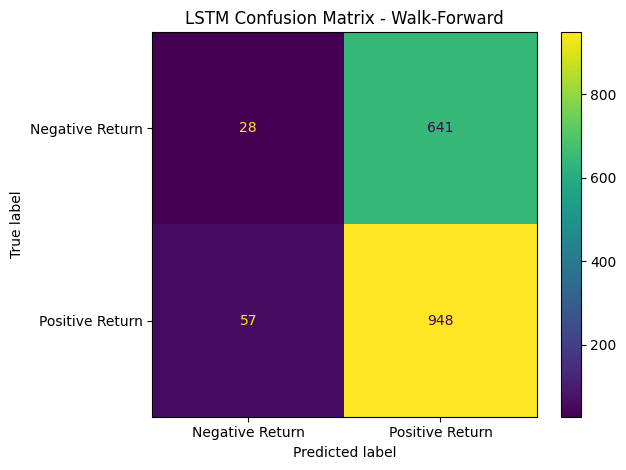

In [17]:
# ============================================================
# 15. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_true,
    y_pred
)

cm_display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Negative Return",
        "Positive Return"
    ]
)

cm_display.plot(
    values_format="d"
)

plt.title(
    "LSTM Confusion Matrix - Walk-Forward"
)

plt.tight_layout()
plt.show()

In [18]:
# ============================================================
# 16. FUNCTIONS FOR THRESHOLD TESTING
# ============================================================

def create_portfolio_from_predictions(results):
    portfolio_rows = []

    for date, month_data in results.groupby("Date"):
        selected = month_data[
            month_data["Prediction"] == 1
        ]

        if len(selected) > 0:
            portfolio_return = selected["Next_Return"].mean()
            selected_assets = selected["Asset"].tolist()
        else:
            portfolio_return = 0.0
            selected_assets = []

        portfolio_rows.append({
            "Date": date,
            "Portfolio_Return": portfolio_return,
            "Selected_Assets": selected_assets,
            "Number_of_Assets": len(selected_assets)
        })

    return (
        pd.DataFrame(portfolio_rows)
        .sort_values("Date")
        .reset_index(drop=True)
    )


def calculate_portfolio_metrics(monthly_returns):
    monthly_returns = pd.Series(
        monthly_returns
    ).dropna().astype(float)

    number_of_months = len(monthly_returns)
    years = number_of_months / 12

    cumulative_growth = (
        1 + monthly_returns
    ).prod()

    cagr = (
        cumulative_growth ** (1 / years)
    ) - 1

    annual_volatility = (
        monthly_returns.std(ddof=1)
        * np.sqrt(12)
    )

    annual_return = monthly_returns.mean() * 12

    sharpe_ratio = (
        annual_return / annual_volatility
        if annual_volatility > 0
        else np.nan
    )

    cumulative_curve = (
        1 + monthly_returns
    ).cumprod()

    running_max = cumulative_curve.cummax()

    drawdown = (
        cumulative_curve / running_max
    ) - 1

    maximum_drawdown = drawdown.min()

    return {
        "CAGR": cagr,
        "Annual Volatility": annual_volatility,
        "Sharpe Ratio": sharpe_ratio,
        "Maximum Drawdown": maximum_drawdown
    }

In [19]:
# ============================================================
# TEST DIFFERENT THRESHOLDS
# ============================================================

thresholds = [0.50, 0.55, 0.60, 0.65, 0.70]

threshold_summary = []

for threshold in thresholds:

    temp_results = lstm_results.copy()

    temp_results["Prediction"] = (
        temp_results["Probability"] >= threshold
    ).astype(int)

    y_true_temp = temp_results["Actual"]
    y_pred_temp = temp_results["Prediction"]

    accuracy = accuracy_score(
        y_true_temp,
        y_pred_temp
    )

    macro_f1 = f1_score(
        y_true_temp,
        y_pred_temp,
        average="macro",
        zero_division=0
    )

    negative_f1 = f1_score(
        y_true_temp,
        y_pred_temp,
        pos_label=0,
        zero_division=0
    )

    positive_f1 = f1_score(
        y_true_temp,
        y_pred_temp,
        pos_label=1,
        zero_division=0
    )

    portfolio = create_portfolio_from_predictions(
        temp_results
    )

    performance = calculate_portfolio_metrics(
        portfolio["Portfolio_Return"]
    )

    threshold_summary.append({
        "Threshold": threshold,
        "Accuracy": accuracy,
        "Macro F1": macro_f1,
        "Negative F1": negative_f1,
        "Positive F1": positive_f1,
        "CAGR": performance["CAGR"],
        "Annual Volatility": performance["Annual Volatility"],
        "Sharpe Ratio": performance["Sharpe Ratio"],
        "Maximum Drawdown": performance["Maximum Drawdown"]
    })

threshold_summary_df = pd.DataFrame(
    threshold_summary
)

display(threshold_summary_df.round(4))

,Threshold,Accuracy,Macro F1,Negative F1,Positive F1,CAGR,Annual Volatility,Sharpe Ratio,Maximum Drawdown
0,0.50,0.5830,0.4026,0.0743,0.7309,0.1685,0.1386,1.1993,-0.3117
1,0.55,0.5191,0.4889,0.3646,0.6132,0.1839,0.1630,1.1224,-0.2969
2,0.60,0.4146,0.3694,0.5382,0.2007,0.1803,0.2183,0.8671,-0.3018
3,0.65,0.4026,0.3033,0.5663,0.0403,0.0380,0.1426,0.3287,-0.2682
4,0.70,0.4014,0.2905,0.5711,0.0099,0.0049,0.0754,0.1029,-0.2283


In [20]:
threshold_display = threshold_summary_df.copy()

for column in [
    "Accuracy",
    "Macro F1",
    "Negative F1",
    "Positive F1"
]:
    threshold_display[column] = (
        threshold_display[column] * 100
    )

for column in [
    "CAGR",
    "Annual Volatility",
    "Maximum Drawdown"
]:
    threshold_display[column] = (
        threshold_display[column] * 100
    )

display(threshold_display.round(2))

,Threshold,Accuracy,Macro F1,Negative F1,Positive F1,CAGR,Annual Volatility,Sharpe Ratio,Maximum Drawdown
0,0.50,58.30,40.26,7.43,73.09,16.85,13.86,1.20,-31.17
1,0.55,51.91,48.89,36.46,61.32,18.39,16.30,1.12,-29.69
2,0.60,41.46,36.94,53.82,20.07,18.03,21.83,0.87,-30.18
3,0.65,40.26,30.33,56.63,4.03,3.80,14.26,0.33,-26.82
4,0.70,40.14,29.05,57.11,0.99,0.49,7.54,0.10,-22.83


In [21]:
best_sharpe_row = threshold_summary_df.loc[
    threshold_summary_df["Sharpe Ratio"].idxmax()
]

print("Best threshold by Sharpe Ratio:")
print(best_sharpe_row)

Best threshold by Sharpe Ratio:
Threshold            0.500000
Accuracy             0.583035
Macro F1             0.402594
Negative F1          0.074271
Positive F1          0.730918
CAGR                 0.168503
Annual Volatility    0.138625
Sharpe Ratio         1.199326
Maximum Drawdown    -0.311669
Name: 0, dtype: float64


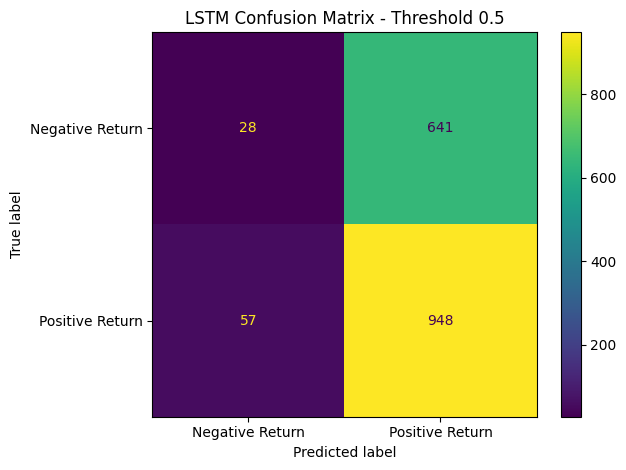

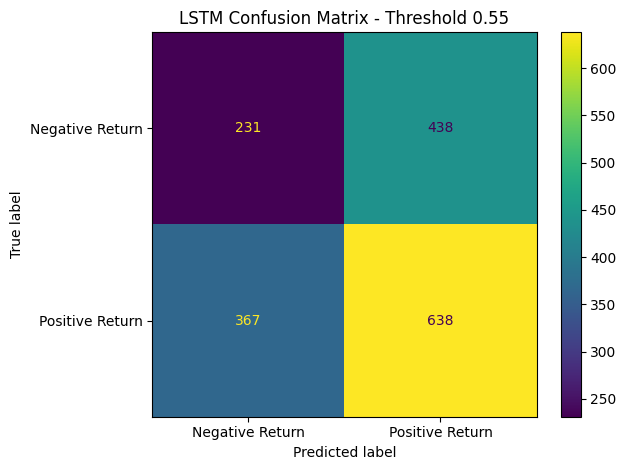

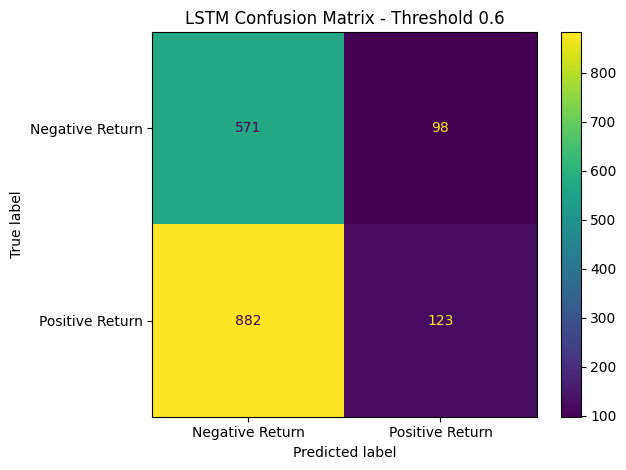

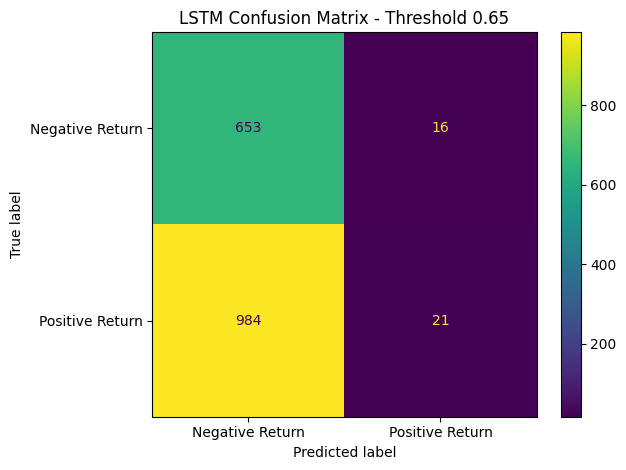

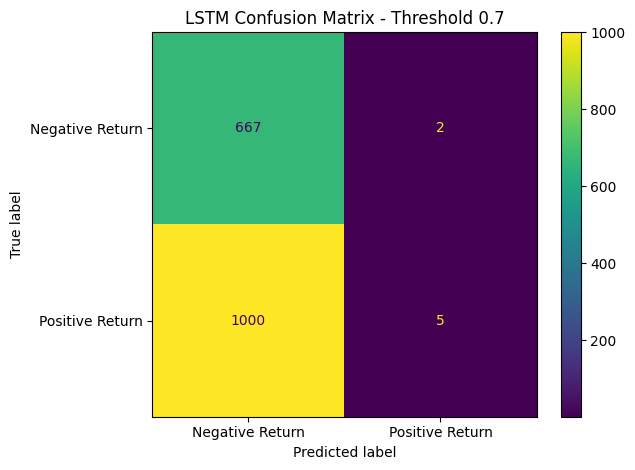

In [22]:
for threshold in thresholds:

    temp_predictions = (
        lstm_results["Probability"] >= threshold
    ).astype(int)

    cm = confusion_matrix(
        lstm_results["Actual"],
        temp_predictions
    )

    display_cm = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=[
            "Negative Return",
            "Positive Return"
        ]
    )

    display_cm.plot(
        values_format="d"
    )

    plt.title(
        f"LSTM Confusion Matrix - Threshold {threshold}"
    )

    plt.tight_layout()
    plt.show()

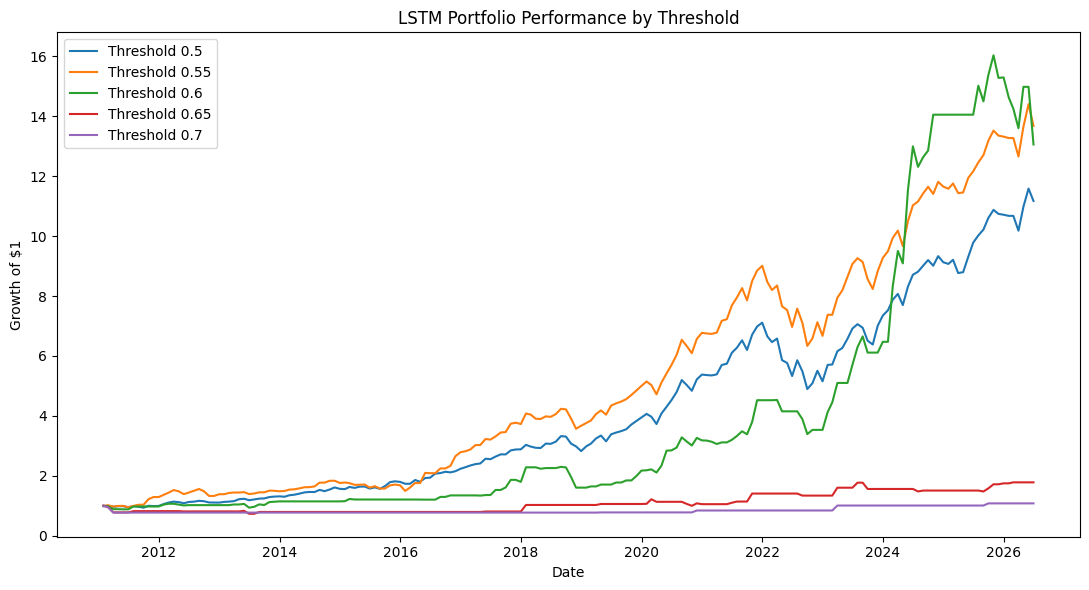

In [23]:
plt.figure(figsize=(11, 6))

for threshold in thresholds:

    temp_results = lstm_results.copy()

    temp_results["Prediction"] = (
        temp_results["Probability"] >= threshold
    ).astype(int)

    portfolio = create_portfolio_from_predictions(
        temp_results
    )

    portfolio["Growth_of_1"] = (
        1 + portfolio["Portfolio_Return"]
    ).cumprod()

    plt.plot(
        portfolio["Date"],
        portfolio["Growth_of_1"],
        label=f"Threshold {threshold}"
    )

plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.title("LSTM Portfolio Performance by Threshold")
plt.legend()
plt.tight_layout()
plt.show()

In [25]:
# ============================================================
# CREATE FINAL LSTM PORTFOLIO
# ============================================================

FINAL_THRESHOLD = 0.50

final_lstm_results = lstm_results.copy()

final_lstm_results["Prediction"] = (
    final_lstm_results["Probability"] >= FINAL_THRESHOLD
).astype(int)

lstm_portfolio = create_portfolio_from_predictions(
    final_lstm_results
)

print("Final threshold:", FINAL_THRESHOLD)
print("LSTM portfolio shape:", lstm_portfolio.shape)

display(lstm_portfolio.head())
display(lstm_portfolio.tail())

Final threshold: 0.5
LSTM portfolio shape: (186, 4)


,Date,Portfolio_Return,Selected_Assets,Number_of_Assets
0,2011-01-31,-0.015512,"[IEF, TLT]",2
1,2011-02-28,0.012863,"[AAPL, EFA, IEF, MSFT, NVDA, QQQ, SPY, TLT, VNQ]",9
2,2011-03-31,-0.032115,"[AAPL, EFA, IEF, MSFT, NVDA, QQQ, SPY, TLT, VNQ]",9
3,2011-04-30,0.020893,"[IEF, MSFT, TLT]",3
4,2011-05-31,-0.000642,"[AAPL, EFA, IEF, MSFT, NVDA, QQQ, SPY, TLT, VNQ]",9


,Date,Portfolio_Return,Selected_Assets,Number_of_Assets
181,2026-02-28,-0.000021,"[AAPL, EFA, IEF, MSFT, NVDA, QQQ, SPY, TLT, VNQ]",9
182,2026-03-31,-0.046354,"[AAPL, EFA, IEF, MSFT, NVDA, QQQ, SPY, TLT, VNQ]",9
183,2026-04-30,0.078514,"[AAPL, EFA, IEF, MSFT, NVDA, QQQ, SPY, TLT, VNQ]",9
184,2026-05-31,0.055192,"[AAPL, EFA, IEF, MSFT, NVDA, QQQ, SPY, TLT, VNQ]",9
185,2026-06-30,-0.035710,"[AAPL, EFA, IEF, MSFT, NVDA, QQQ, SPY, TLT, VNQ]",9


In [26]:
# ============================================================
# COMPARE LSTM WITH TRADITIONAL BENCHMARKS
# ============================================================

from scipy.optimize import minimize

# ------------------------------------------------------------
# 1. SPY buy-and-hold monthly returns
# ------------------------------------------------------------

spy_returns = (
    monthly.loc[
        monthly["Asset"] == "SPY",
        ["Date", "Return_1M"]
    ]
    .rename(columns={"Return_1M": "SPY"})
)


# ------------------------------------------------------------
# 2. Equal-weight portfolio
# ------------------------------------------------------------

equal_weight_returns = (
    monthly
    .groupby("Date", as_index=False)["Return_1M"]
    .mean()
    .rename(columns={"Return_1M": "Equal Weight"})
)


# ------------------------------------------------------------
# 3. 60/40 portfolio
# 60% SPY + 40% TLT
# ------------------------------------------------------------

spy_6040 = (
    monthly.loc[
        monthly["Asset"] == "SPY",
        ["Date", "Return_1M"]
    ]
    .rename(columns={"Return_1M": "SPY_60_40"})
)

tlt_6040 = (
    monthly.loc[
        monthly["Asset"] == "TLT",
        ["Date", "Return_1M"]
    ]
    .rename(columns={"Return_1M": "TLT_60_40"})
)

portfolio_6040 = pd.merge(
    spy_6040,
    tlt_6040,
    on="Date",
    how="inner"
)

portfolio_6040["60/40 Portfolio"] = (
    0.60 * portfolio_6040["SPY_60_40"]
    + 0.40 * portfolio_6040["TLT_60_40"]
)

portfolio_6040 = portfolio_6040[
    ["Date", "60/40 Portfolio"]
]


# ------------------------------------------------------------
# 4. LSTM portfolio returns
# ------------------------------------------------------------

lstm_returns = (
    lstm_portfolio[
        ["Date", "Portfolio_Return"]
    ]
    .rename(columns={"Portfolio_Return": "LSTM"})
)


# ------------------------------------------------------------
# 5. Mean-Variance Optimization benchmark
# ------------------------------------------------------------

monthly_returns_wide = (
    monthly
    .pivot(
        index="Date",
        columns="Asset",
        values="Return_1M"
    )
    .sort_index()
)

mvo_assets = monthly_returns_wide.columns.tolist()


def calculate_mvo_weights(
    historical_returns,
    risk_free_rate=0.0
):
    """
    Long-only maximum-Sharpe Mean-Variance portfolio.

    Constraints:
    - weights sum to 1
    - no short selling
    """

    historical_returns = (
        historical_returns
        .dropna(axis=0, how="any")
    )

    number_of_assets = historical_returns.shape[1]

    equal_weights = np.repeat(
        1 / number_of_assets,
        number_of_assets
    )

    if len(historical_returns) < 12:
        return equal_weights

    expected_annual_returns = (
        historical_returns.mean() * 12
    ).to_numpy()

    annual_covariance = (
        historical_returns.cov() * 12
    ).to_numpy()

    def negative_sharpe(weights):
        portfolio_return = np.dot(
            weights,
            expected_annual_returns
        )

        portfolio_variance = np.dot(
            weights,
            np.dot(
                annual_covariance,
                weights
            )
        )

        portfolio_volatility = np.sqrt(
            max(portfolio_variance, 0)
        )

        if portfolio_volatility <= 0:
            return 1e6

        sharpe_ratio = (
            portfolio_return - risk_free_rate
        ) / portfolio_volatility

        return -sharpe_ratio

    bounds = [
        (0.0, 1.0)
        for _ in range(number_of_assets)
    ]

    constraints = {
        "type": "eq",
        "fun": lambda weights: np.sum(weights) - 1
    }

    result = minimize(
        negative_sharpe,
        equal_weights,
        method="SLSQP",
        bounds=bounds,
        constraints=constraints,
        options={
            "maxiter": 1000,
            "ftol": 1e-9
        }
    )

    if not result.success:
        return equal_weights

    return result.x


mvo_records = []

for test_date in pd.to_datetime(
    lstm_returns["Date"]
).sort_values():

    historical_returns = monthly_returns_wide.loc[
        monthly_returns_wide.index < test_date,
        mvo_assets
    ]

    current_returns = monthly_returns_wide.loc[
        test_date,
        mvo_assets
    ]

    weights = calculate_mvo_weights(
        historical_returns=historical_returns,
        risk_free_rate=0.0
    )

    mvo_return = np.dot(
        weights,
        current_returns.to_numpy()
    )

    mvo_records.append({
        "Date": test_date,
        "Mean-Variance": float(mvo_return)
    })

mean_variance_returns = pd.DataFrame(
    mvo_records
)


# ------------------------------------------------------------
# 6. Merge all strategies using the same dates
# ------------------------------------------------------------

comparison_returns = (
    lstm_returns
    .merge(
        spy_returns,
        on="Date",
        how="inner"
    )
    .merge(
        equal_weight_returns,
        on="Date",
        how="inner"
    )
    .merge(
        portfolio_6040,
        on="Date",
        how="inner"
    )
    .merge(
        mean_variance_returns,
        on="Date",
        how="inner"
    )
    .dropna()
    .sort_values("Date")
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 7. Check final comparison data
# ------------------------------------------------------------

display(comparison_returns.head())
display(comparison_returns.tail())

print(
    "Comparison period:",
    comparison_returns["Date"].min(),
    "to",
    comparison_returns["Date"].max()
)

print(
    "Number of comparison months:",
    len(comparison_returns)
)

print(
    "Strategies:",
    comparison_returns.columns.tolist()
)

,Date,LSTM,SPY,Equal Weight,60/40 Portfolio,Mean-Variance
0,2011-01-31,-0.015512,0.023300,0.074753,0.001656,0.011251
1,2011-02-28,0.012863,0.034737,0.012863,0.027443,0.002818
2,2011-03-31,-0.032115,0.000120,-0.032115,0.000189,-0.006965
3,2011-04-30,0.020893,0.028961,0.035796,0.026734,0.017102
4,2011-05-31,-0.000642,-0.011215,-0.000642,0.006963,0.020050


,Date,LSTM,SPY,Equal Weight,60/40 Portfolio,Mean-Variance
181,2026-02-28,-0.000021,-0.008642,-0.000021,0.013350,0.005522
182,2026-03-31,-0.046354,-0.049380,-0.046354,-0.046548,-0.027370
183,2026-04-30,0.078514,0.105053,0.078514,0.059673,0.030069
184,2026-05-31,0.055192,0.052626,0.055192,0.033709,0.035355
185,2026-06-30,-0.035710,-0.017940,-0.035710,-0.001277,-0.030443


Comparison period: 2011-01-31 00:00:00 to 2026-06-30 00:00:00
Number of comparison months: 186
Strategies: ['Date', 'LSTM', 'SPY', 'Equal Weight', '60/40 Portfolio', 'Mean-Variance']


In [27]:
# ============================================================
# CALCULATE PERFORMANCE METRICS
# ============================================================

strategy_columns = [
    "SPY",
    "Equal Weight",
    "60/40 Portfolio",
    "Mean-Variance",
    "LSTM"
]

comparison_rows = []

for strategy in strategy_columns:

    metrics = calculate_portfolio_metrics(
        comparison_returns[strategy]
    )

    comparison_rows.append({
        "Portfolio": strategy,
        "CAGR": metrics["CAGR"] * 100,
        "Annual Volatility":
            metrics["Annual Volatility"] * 100,
        "Sharpe Ratio":
            metrics["Sharpe Ratio"],
        "Maximum Drawdown":
            metrics["Maximum Drawdown"] * 100
    })

benchmark_comparison_table = pd.DataFrame(
    comparison_rows
)

display(
    benchmark_comparison_table.round(2)
)

,Portfolio,CAGR,Annual Volatility,Sharpe Ratio,Maximum Drawdown
0,SPY,14.12,14.15,1.01,-23.93
1,Equal Weight,17.30,13.94,1.22,-30.23
2,60/40 Portfolio,9.78,9.94,0.99,-26.21
3,Mean-Variance,8.12,7.90,1.03,-20.23
4,LSTM,16.85,13.86,1.20,-31.17


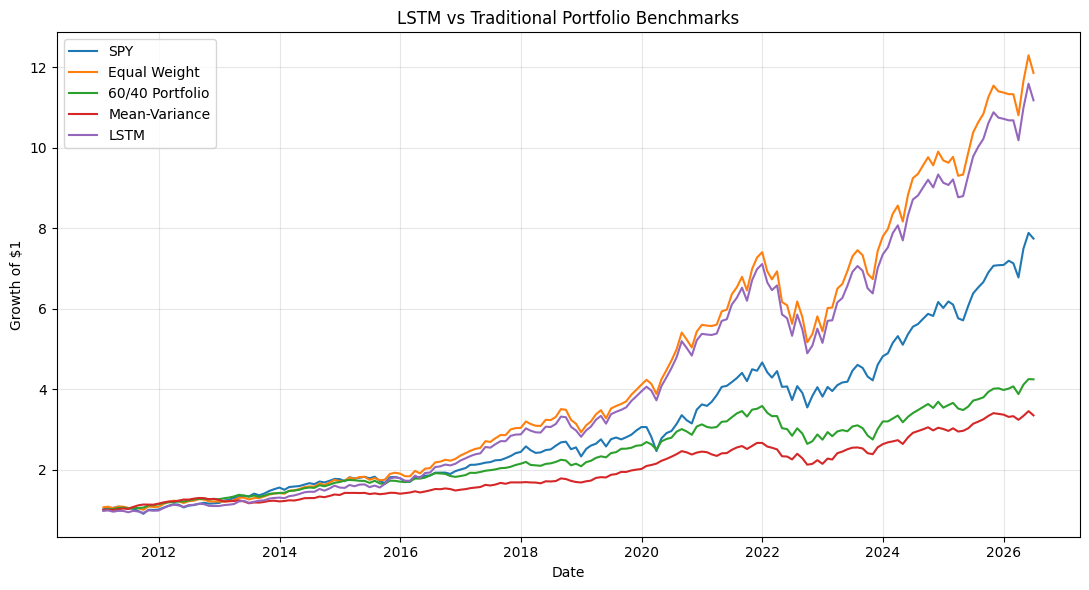

In [28]:
# ============================================================
# PLOT LSTM VS TRADITIONAL BENCHMARKS
# ============================================================

plt.figure(figsize=(11, 6))

for strategy in strategy_columns:

    growth = (
        1 + comparison_returns[strategy]
    ).cumprod()

    plt.plot(
        comparison_returns["Date"],
        growth,
        label=strategy
    )

plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.title(
    "LSTM vs Traditional Portfolio Benchmarks"
)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()